##1. Importando Bibliotecas



In [320]:
# Importando as principais bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score



##2. Carregando o Conjunto de Dados




In [321]:
# Importando os arquivos (DataFrames) para análise de dados. Obs.: Via google drive
df_app = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/FASE_2_PÓS_TECH/DESAFIO_PÓS_TECH_FASE_2/BASE/application_record.csv", sep=",")
df_cre = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/FASE_2_PÓS_TECH/DESAFIO_PÓS_TECH_FASE_2/BASE/credit_record.csv", sep = ",")

In [322]:
# Analisando as primeiras linhas para ver se o dataframe importou certo
df_app.head(3)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0


In [323]:
# Analisando as primeiras linhas para ver se o dataframe importou certo
df_cre.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


##3. Análise Exploratória de Dados

In [324]:
# Saber qtd de linhas x colunas
df_app.shape

(438557, 18)

In [325]:
df_cre.shape

(1048575, 3)

In [326]:
df_app["ID"].nunique()

438510

In [327]:
df_cre["ID"].nunique()

45985

In [328]:
df_app.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [329]:
df_app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

## 4. Pré-processamento de Dados

In [330]:
df_app.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [331]:
df_app["OCCUPATION_TYPE"].value_counts().sort_values()

,count
OCCUPATION_TYPE,
IT staff,604
HR staff,774
Realty agents,1041
Waiters/barmen staff,1665
Secretaries,2044
Low-skill Laborers,2140
Private service staff,3456
Cleaning staff,5845
Security staff,7993


In [332]:
# Transforma valor nulo em "Não informado", visto que é tipo de ocupação
df_app["OCCUPATION_TYPE"] = df_app["OCCUPATION_TYPE"].fillna("Nao_Informado")

In [333]:
df_app["OCCUPATION_TYPE"].value_counts().sort_values()

,count
OCCUPATION_TYPE,
IT staff,604
HR staff,774
Realty agents,1041
Waiters/barmen staff,1665
Secretaries,2044
Low-skill Laborers,2140
Private service staff,3456
Cleaning staff,5845
Security staff,7993


In [334]:
df_cre.isnull().sum()

,0
ID,0
MONTHS_BALANCE,0
STATUS,0


In [335]:
df_cre["STATUS"].unique()

array(['X', '0', 'C', '1', '2', '3', '4', '5'], dtype=object)

In [336]:
df_cre["STATUS"].value_counts().sort_index()

,count
STATUS,
0,383120
1,11090
2,868
3,320
4,223
5,1693
C,442031
X,209230


In [337]:
#def classificar_status (coluna_status):
#  if coluna_status in ["2","3","4","5"]:
#    return 1
#  return 0


## def classificar_status(STATUS):
##    if str(STATUS) in ["0", "C"]:
##        return 0
##    elif str(STATUS) in ["1", "2", "3", "4", "5"]:
##        return 1
##    elif str(STATUS) == "X":
##        return 2
##    else:
##        return 2


def classificar_status(STATUS):
    STATUS = set(STATUS.astype(str))

    if STATUS.intersection({"2","3", "4", "5"}):
        return "Mau pagador"

    elif STATUS.intersection({"1"}):
        return "Atraso menor (30d)"

    elif STATUS.intersection({"0", "C"}):
        return "Bom pagador"

   # elif STATUS.intersection({"X"}):
    #    return "Sem Informação"

    else:
        return "Sem informação"

In [338]:
classificacao = (
    df_cre.groupby("ID")["STATUS"]
    .apply(classificar_status)
    .reset_index(name="TIPO_CLIENTE")
)

# df_cre = df_cre.join(classificacao, on="ID")

In [339]:
classificacao["TIPO_CLIENTE"].value_counts()

,count
TIPO_CLIENTE,
Bom pagador,36099
Atraso menor (30d),4683
Sem informação,4536
Mau pagador,667


In [340]:
classificacao

,ID,TIPO_CLIENTE
0,5001711,Bom pagador
1,5001712,Bom pagador
2,5001713,Sem informação
3,5001714,Sem informação
4,5001715,Sem informação
...,...,...
45980,5150482,Bom pagador
45981,5150483,Sem informação
45982,5150484,Bom pagador
45983,5150485,Bom pagador


In [341]:
classificacao["TIPO_CLIENTE"].value_counts().sort_index()   # O sort_index() ordena de forma crescente o tipo de TIPO DE CLIENTE

,count
TIPO_CLIENTE,
Atraso menor (30d),4683
Bom pagador,36099
Mau pagador,667
Sem informação,4536


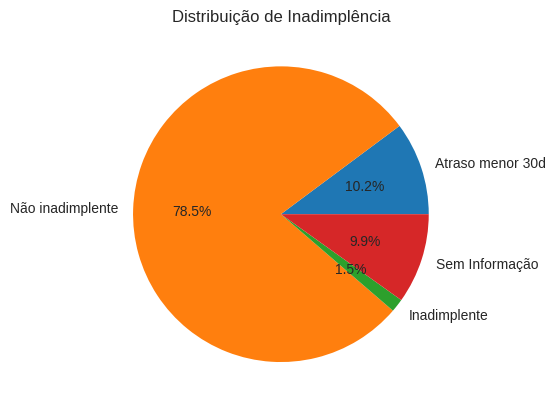

In [342]:
grafico = classificacao["TIPO_CLIENTE"].value_counts().sort_index()

plt.pie(
    grafico,
    labels=["Atraso menor 30d","Não inadimplente", "Inadimplente","Sem Informação" ],
    autopct="%1.1f%%"
)

plt.title("Distribuição de Inadimplência")
plt.show()

In [343]:
classificacao["TIPO_CLIENTE"].value_counts(dropna=False)

,count
TIPO_CLIENTE,
Bom pagador,36099
Atraso menor (30d),4683
Sem informação,4536
Mau pagador,667


In [344]:
df_final = pd.merge(
    df_app,
    classificacao,
    on="ID",
    how='inner'
)

In [345]:
df_final.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TIPO_CLIENTE
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Nao_Informado,2.0,Atraso menor (30d)
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Nao_Informado,2.0,Atraso menor (30d)
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,Bom pagador
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,Bom pagador
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,Sem informação


In [346]:
df_final.shape

(36457, 19)

In [347]:
df_final["ID"].nunique()

36457

In [348]:
print("IDs df_app:", df_app['ID'].nunique())
print("IDs classificação:", classificacao['ID'].nunique())
print("IDs df_final:", df_final['ID'].nunique())

IDs df_app: 438510
IDs classificação: 45985
IDs df_final: 36457


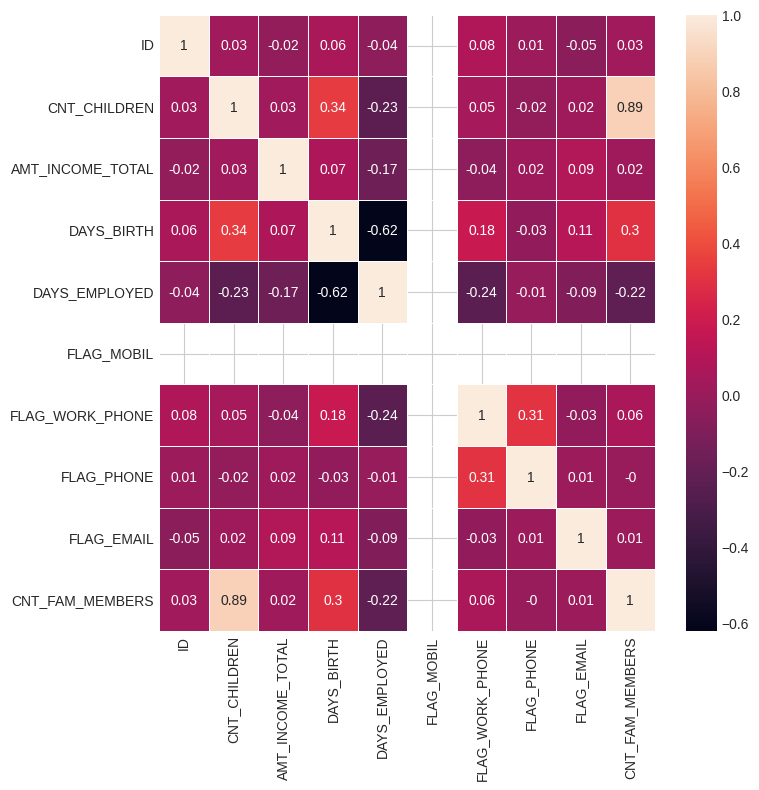

In [349]:
correlation_matrix = df_final.select_dtypes(include="number").corr().round(2)

fig, ax = plt.subplots(figsize=(8,8))
sns.heatmap(data=correlation_matrix, annot = True, linewidths=.5, ax=ax)
plt.show()

In [350]:
# RETIRANDO OS STATUS "SEM INFORMAÇÃO" da colune TIPO_CLIENTE para poder criar coluna TARGET com 0 ou 1

df_final = df_final[df_final['TIPO_CLIENTE'] != 'Sem informação'].copy()
print(df_final['TIPO_CLIENTE'].value_counts())

TIPO_CLIENTE
Bom pagador           28819
Atraso menor (30d)     3675
Mau pagador             616
Name: count, dtype: int64


In [351]:
# Escolher par aonde o Atraso menor (30d) vai. Nesse momento, tolerância Zero então vai para mau pagador

# Criar dicionário de mapeamento
# (Aqui consideramos 'Atraso menor (30d)' como 0/Bom pagador.)
mapeamento = {
    'Bom pagador': 0,
    'Atraso menor (30d)': 0,
    'Mau pagador': 1
}

# Criar a nova coluna target numérica
df_final['TARGET'] = df_final['TIPO_CLIENTE'].map(mapeamento)

# Verificar a distribuição
print(df_final['TARGET'].value_counts())

TARGET
0    32494
1      616
Name: count, dtype: int64


In [352]:
df_final["TARGET"].value_counts().sort_index()

,count
TARGET,
0,32494
1,616


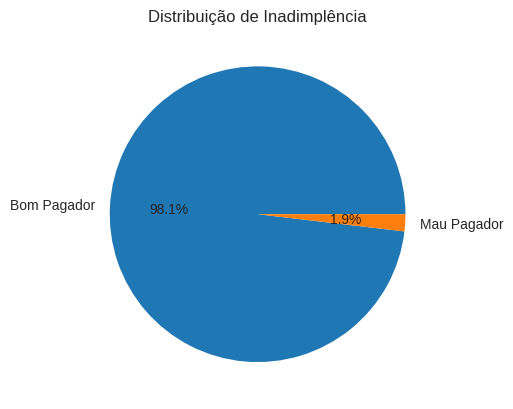

In [353]:
grafico = df_final["TARGET"].value_counts().sort_index()

plt.pie(
    grafico,
    labels=["Bom Pagador","Mau Pagador" ],
    autopct="%1.1f%%"
)

plt.title("Distribuição de Inadimplência")
plt.show()

In [354]:
# TRANFORMAÇÕES: IDADES E DIAS EMPREGADOS ESTÃO EM VALORES NEGATIVOS

# 1. Carregar a base de dados
df = df_final

# Idade em anos inteiros
df['IDADE'] = (np.abs(df['DAYS_BIRTH']) / 365).astype(int)



In [355]:
# 1. Carregar a base
df1 = df_final

# 2. Converte valores negativos para anos de trabalho (positivos) e atribui 0 para quem for aposentado/desempregado
df1['ANOS_TRABALHADOS'] = np.where(
    df['DAYS_EMPLOYED'] < 0,
    (np.abs(df['DAYS_EMPLOYED']) / 365).round(1),
    0
)


In [356]:
df_final.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TIPO_CLIENTE,TARGET,IDADE,ANOS_TRABALHADOS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Nao_Informado,2.0,Atraso menor (30d),0,32,12.4
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Nao_Informado,2.0,Atraso menor (30d),0,32,12.4
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,1,0,0,0,Security staff,2.0,Bom pagador,0,58,3.1
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,0,1,1,Sales staff,1.0,Bom pagador,0,52,8.4
5,5008810,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,0,1,1,Sales staff,1.0,Bom pagador,0,52,8.4


## CONTINUA 4. Pré-processamento de Dados

In [357]:
features_num = [
    'AMT_INCOME_TOTAL',
    'IDADE',
    'ANOS_TRABALHADOS',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS',
]

X = df[features_num]
y = df['TARGET']

In [358]:
# Dividimos os dados em conjuntos de treinamento e teste.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=123,
    stratify=y
)

In [359]:
# Escalonamos os dados para melhorar o desempenho de alguns algoritmos.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [360]:
# Balancer os dados dos treino
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=123)
X_train, y_train = smote.fit_resample(X_train, y_train)


## 5. Modelos de Aprendizado Supervisionado

In [361]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [362]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)

In [363]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

In [364]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=100)
forest.fit(X_train, y_train)
y_pred_forest = forest.predict(X_test)

In [365]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

##6. Avaliação dos Modelos

In [366]:
#Criamos uma função para avaliar os modelos de forma consistente.

def avaliar_modelo(y_test, y_pred, nome_modelo):
    print(f"Resultados para {nome_modelo}:")
    print("Acurácia:", accuracy_score(y_test, y_pred))
    print("Matriz de Confusão:\n", confusion_matrix(y_test, y_pred))
    print("Relatório de Classificação:\n", classification_report(y_test, y_pred))
    print("-" * 60)

In [367]:
avaliar_modelo(y_test, y_pred_knn, "K-Nearest Neighbors")
avaliar_modelo(y_test, y_pred_logreg, "Regressão Logística")
avaliar_modelo(y_test, y_pred_tree, "Árvore de Decisão")
avaliar_modelo(y_test, y_pred_forest, "Random Forest")
avaliar_modelo(y_test, y_pred_svm, "Support Vector Machine")

Resultados para K-Nearest Neighbors:
Acurácia: 0.9312635902391883
Matriz de Confusão:
 [[7652  472]
 [  97   57]]
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.99      0.94      0.96      8124
           1       0.11      0.37      0.17       154

    accuracy                           0.93      8278
   macro avg       0.55      0.66      0.57      8278
weighted avg       0.97      0.93      0.95      8278

------------------------------------------------------------
Resultados para Regressão Logística:
Acurácia: 0.4073447692679391
Matriz de Confusão:
 [[3269 4855]
 [  51  103]]
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.98      0.40      0.57      8124
           1       0.02      0.67      0.04       154

    accuracy                           0.41      8278
   macro avg       0.50      0.54      0.31      8278
weighted avg       0.97      0.41      0.56      8278


##7. Conclusão

O Random Forest foi o modelo com melhor desempenho estrutural e maior precisão, sendo a base mais sólida entre os testados. No entanto, nenhum dos modelos com o limiar de decisão padrão (0.50) atingiu o desempenho ideal isoladamente.

Para o cenário de negócios, a recomendação é adotar o Random Forest combinando o ajuste fino do limiar de decisão (ponto de corte) para 0.15 ou 0.20. Isso permitirá elevar o Recall da classe 1 para patamares acima de 60-70% sem destruir a precisão do modelo."

##8 - OUTROS/DIVERSOS

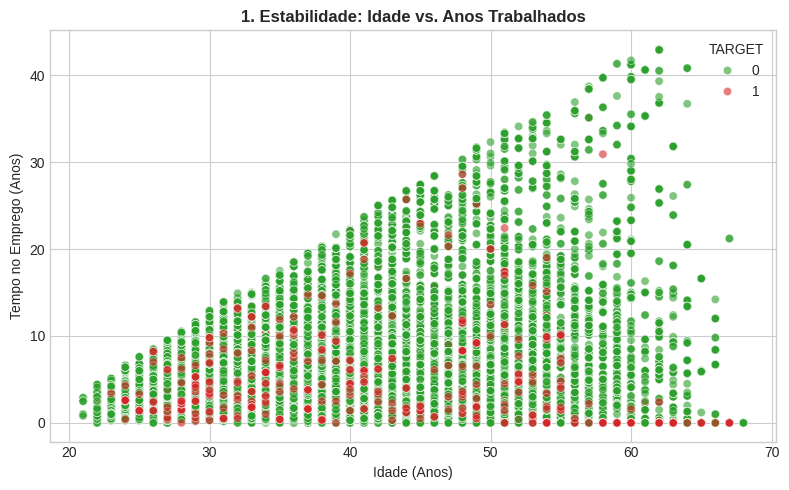

In [368]:
# ALGUNS GRÁFICOS PARA CLAREAR APRESENTAÇÃO

plt.style.use('seaborn-v0_8-whitegrid')

# Criando apenas 1 gráfico (corrigido o figsize)
fig, ax = plt.subplots(figsize=(8, 5))

# GRAFICO 1
sns.scatterplot(
    data=df,
    x='IDADE',
    y='ANOS_TRABALHADOS',
    hue='TARGET',
    palette=['#2ca02c', '#d62728'],
    alpha=0.6,
    ax=ax,
)

ax.set_title('1. Estabilidade: Idade vs. Anos Trabalhados', fontweight='bold')
ax.set_xlabel('Idade (Anos)')
ax.set_ylabel('Tempo no Emprego (Anos)')

plt.tight_layout()
plt.show()



/tmp/ipykernel_2075/220298230.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(


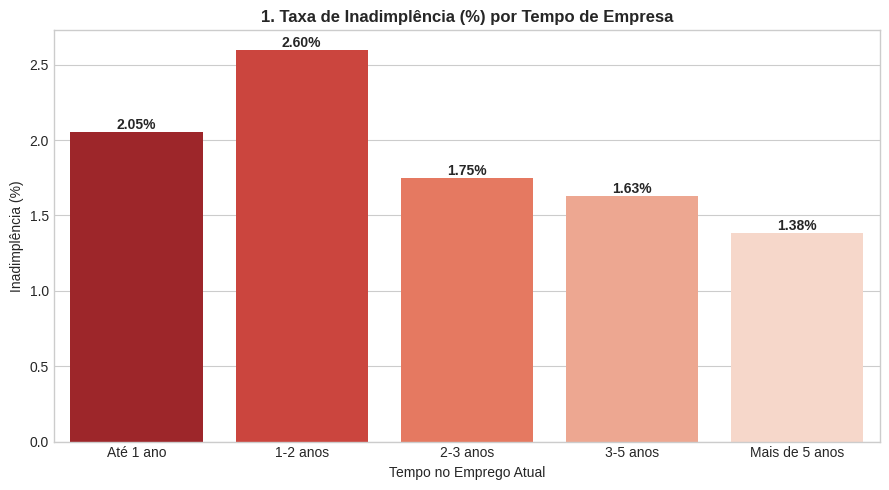

In [369]:
# Faixas de tempo no emprego
df['FAIXA_TRABALHO'] = pd.cut(
    df['ANOS_TRABALHADOS'],
    bins=[-1, 1, 3, 5, 10, 100],
    labels=[
        'Até 1 ano',
        '1-2 anos',
        '2-3 anos',
        '3-5 anos',
        'Mais de 5 anos',
    ],
)

taxa_trabalho = (
    df.groupby('FAIXA_TRABALHO', observed=False)['TARGET'].mean() * 100
)

plt.figure(figsize=(9, 5))
ax1 = sns.barplot(
    x=taxa_trabalho.index, y=taxa_trabalho.values, palette='Reds_r'
)
plt.title(
    '1. Taxa de Inadimplência (%) por Tempo de Empresa',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Tempo no Emprego Atual')
plt.ylabel('Inadimplência (%)')

# Rótulo em cada barra
for p in ax1.patches:
  ax1.annotate(
      f'{p.get_height():.2f}%',
      (p.get_x() + p.get_width() / 2.0, p.get_height()),
      ha='center',
      va='center',
      xytext=(0, 5),
      textcoords='offset points',
      fontweight='bold',
  )

plt.tight_layout()
plt.show()


/tmp/ipykernel_2075/1533066727.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


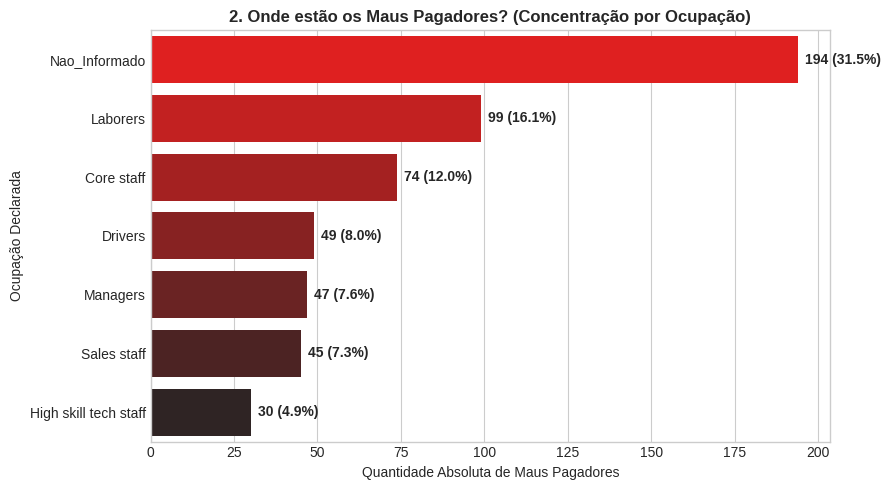

In [370]:
# Filtrar apenas a contagem dos 616 maus pagadores
top_ocupacoes = df[df['TARGET'] == 1]['OCCUPATION_TYPE'].value_counts().head(7)

plt.figure(figsize=(9, 5))
ax2 = sns.barplot(
    x=top_ocupacoes.values, y=top_ocupacoes.index, palette='dark:red_r'
)
plt.title(
    '2. Onde estão os Maus Pagadores? (Concentração por Ocupação)',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Quantidade Absoluta de Maus Pagadores')
plt.ylabel('Ocupação Declarada')

# Rótulo com quantidade e percentual sobre os 616
for p in ax2.patches:
  width = p.get_width()
  ax2.annotate(
      f'{int(width)} ({width/616*100:.1f}%)',
      (width, p.get_y() + p.get_height() / 2.0),
      ha='left',
      va='center',
      xytext=(5, 0),
      textcoords='offset points',
      fontweight='bold',
  )

plt.tight_layout()
plt.show()

/tmp/ipykernel_2075/3135677420.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=contagem_civil.index, y=contagem_civil.values, palette='Reds_d')


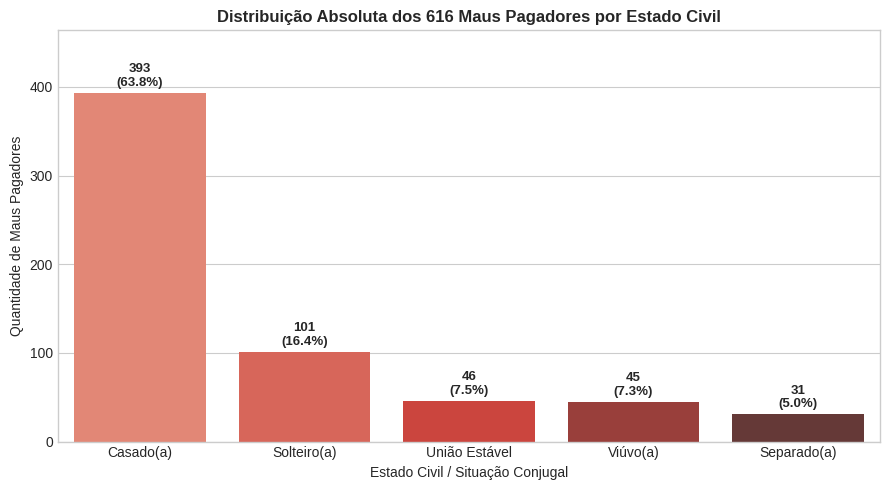

In [371]:
# Filtrar apenas os 616 maus pagadores
df_maus = df[df['TARGET'] == 1].copy()

# Mapear os nomes para português
traducao_civil = {
    'Married': 'Casado(a)',
    'Single / not married': 'Solteiro(a)',
    'Civil marriage': 'União Estável',
    'Separated': 'Separado(a)',
    'Widow': 'Viúvo(a)',
}

df_maus['ESTADO_CIVIL_PT'] = df_maus['NAME_FAMILY_STATUS'].map(
    traducao_civil
)
contagem_civil = df_maus['ESTADO_CIVIL_PT'].value_counts()

#  Gerar o gráfico
plt.figure(figsize=(9, 5))
ax = sns.barplot(x=contagem_civil.index, y=contagem_civil.values, palette='Reds_d')

plt.title(
    'Distribuição Absoluta dos 616 Maus Pagadores por Estado Civil',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Estado Civil / Situação Conjugal')
plt.ylabel('Quantidade de Maus Pagadores')

# Adicionar valores e porcentagens acima das barras
total_maus = len(df_maus)
for p in ax.patches:
  val = int(p.get_height())
  pct = (val / total_maus) * 100
  if val > 0:
    ax.annotate(
        f'{val}\n({pct:.1f}%)',
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 12),
        textcoords='offset points',
        fontweight='bold',
        fontsize=9.5,
    )

plt.ylim(0, max(contagem_civil.values) * 1.18)
plt.tight_layout()
plt.show()